In [9]:
# ==========================================
# PROJECT: Amazon Prime Video Data Analytics
# PHASE 1: Data Loading & Inspection
# ==========================================

In [1]:
# Mount Drive + Create Folders
from google.colab import drive
drive.mount('/content/drive')

import os

# Setting the base path for Amazon Prime Project
base = '/content/drive/MyDrive/amazon-prime-analytics'

os.makedirs(f'{base}/data', exist_ok=True)
os.makedirs(f'{base}/outputs', exist_ok=True)
os.makedirs(f'{base}/notebooks', exist_ok=True)

print("Project folders created!")
print(os.listdir(base))

Mounted at /content/drive
Project folders created!
['data', 'outputs', 'notebooks']


In [2]:
# Install Libraries
!pip install plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

# Formatting visuals
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
sns.set_palette("viridis")

print("Libraries ready! (World Cloud excluded as requested)")

Libraries ready! (World Cloud excluded as requested)


In [4]:
# Upload Amazon Prime Dataset
from google.colab import files
uploaded = files.upload()

Saving amazon_prime_titles.csv to amazon_prime_titles.csv


In [5]:
# Check What Uploaded & Move to Data Folder
import shutil

target_path = f'{base}/data'

for filename in uploaded.keys():
    shutil.copy(filename, f'{target_path}/{filename}')
    print(f"Saved to Drive: {filename}")

print("\nCurrent Data Folder Content:")
print(os.listdir(target_path))

Saved to Drive: amazon_prime_titles.csv

Current Data Folder Content:
['amazon_prime_titles.csv']


In [7]:
df = pd.read_csv(f'{base}/data/amazon_prime_titles.csv')
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2083
cast,1233
country,8996
date_added,9513
release_year,0
rating,337
duration,0


In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [10]:
# ==========================================
# PHASE 2: Data Cleaning & Feature Engineering
# ==========================================

# 1. Handling Missing Values
df['director'].fillna('No Director', inplace=True)
df['cast'].fillna('No Cast', inplace=True)
df['country'].fillna('Unknown Country', inplace=True)
df['rating'].fillna('UNRATED', inplace=True)

# 2. Convert 'date_added' to Datetime and extract features
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# 3. Cleaning 'duration'
# We create a numeric column for minutes and a separate one for Seasons
df['duration_val'] = df['duration'].str.split(' ').str[0].astype(int)
df['duration_unit'] = df['duration'].str.split(' ').str[1]

# 4. Final check of the cleaned data
print("--- Cleaning Complete ---")
print(df.isnull().sum())
print("\nNew Features Added: [year_added, month_added, duration_val, duration_unit]")
df[['title', 'type', 'duration_val', 'year_added']].head()

--- Cleaning Complete ---
show_id             0
type                0
title               0
director            0
cast                0
country             0
date_added       9513
release_year        0
rating              0
duration            0
listed_in           0
description         0
year_added       9513
month_added      9513
duration_val        0
duration_unit       0
dtype: int64

New Features Added: [year_added, month_added, duration_val, duration_unit]


,title,type,duration_val,year_added
0,The Grand Seduction,Movie,113,2021.0
1,Take Care Good Night,Movie,110,2021.0
2,Secrets of Deception,Movie,74,2021.0
3,Pink: Staying True,Movie,69,2021.0
4,Monster Maker,Movie,45,2021.0


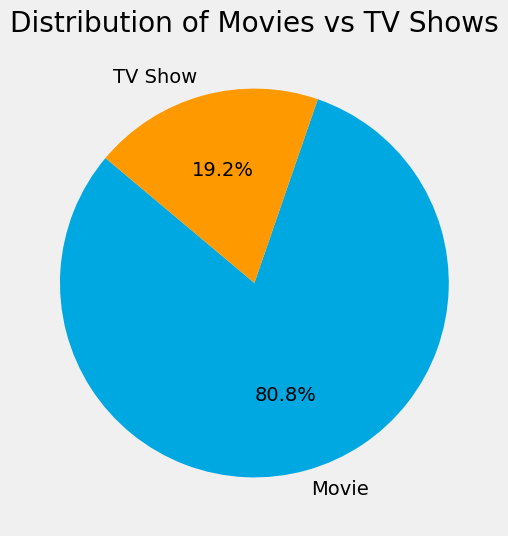

In [11]:
# 1. Content Type Distribution
plt.figure(figsize=(10, 6))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#00A8E1', '#FF9900'])
plt.title('Distribution of Movies vs TV Shows')
plt.show()

# Insight for README: Amazon Prime is heavily movie-centric compared to competitors like Netflix.

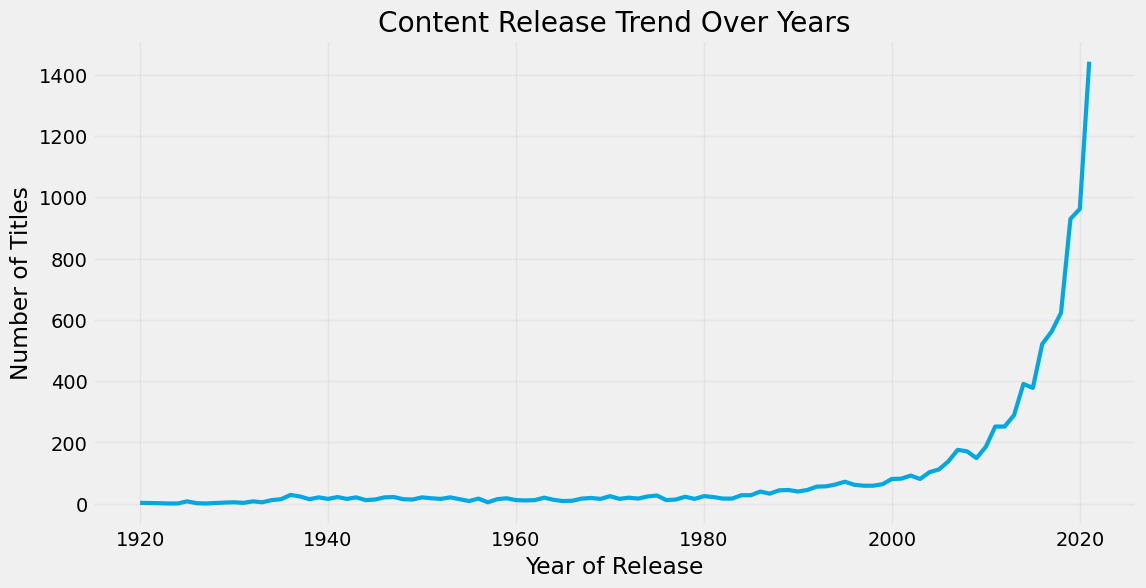

In [12]:
# 2. Release Trends over the Years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['release_year'].value_counts().sort_index(), color='#00A8E1', linewidth=3)
plt.title('Content Release Trend Over Years')
plt.xlabel('Year of Release')
plt.ylabel('Number of Titles')
plt.grid(alpha=0.3)
plt.show()

# Insight for README: Check for a spike around 2018-2021 which indicates aggressive market capture.

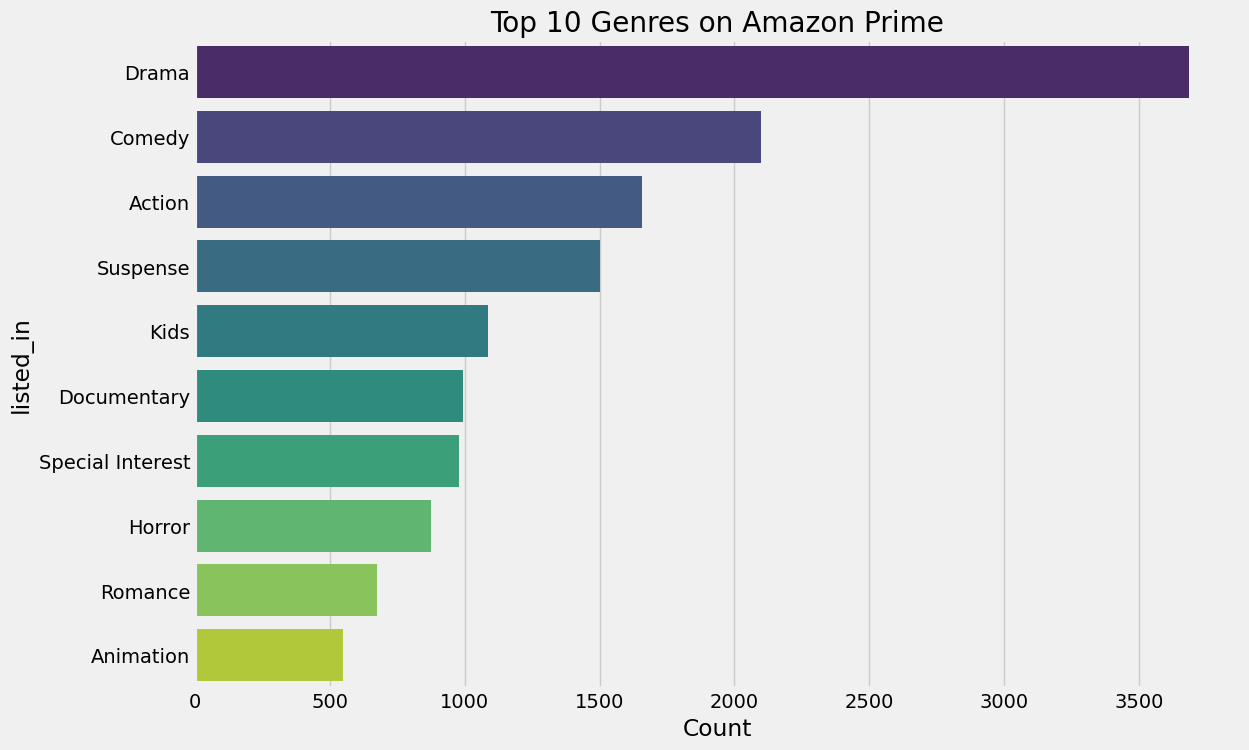

In [13]:
# 3. Top 10 Genres
# Since 'listed_in' contains multiple genres, we split and count them
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres on Amazon Prime')
plt.xlabel('Count')
plt.show()

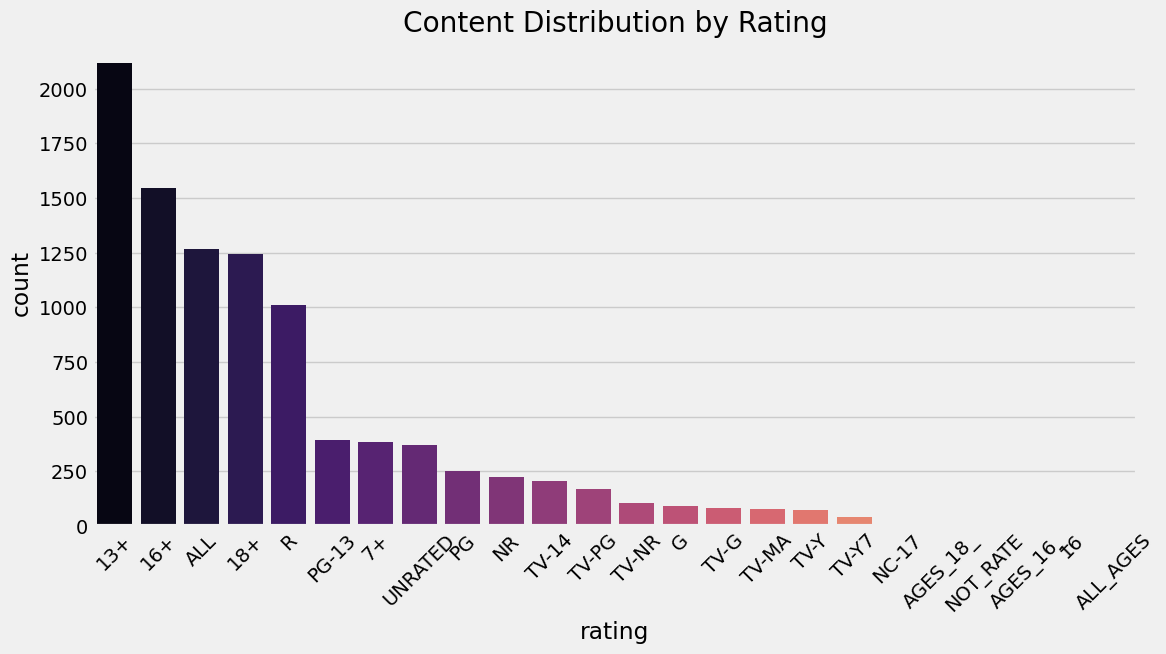

In [14]:
# 4. Content Ratings Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='magma')
plt.title('Content Distribution by Rating')
plt.xticks(rotation=45)
plt.show()

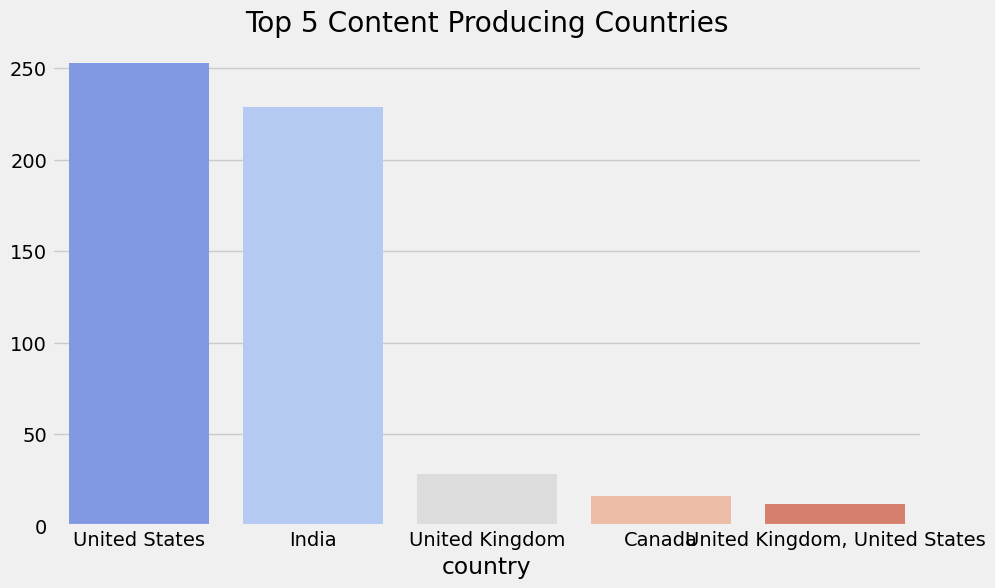

In [15]:
# 5. Top 5 Countries Contributing Content (Excluding Unknown)
country_counts = df[df['country'] != 'Unknown Country']['country'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='coolwarm')
plt.title('Top 5 Content Producing Countries')
plt.show()

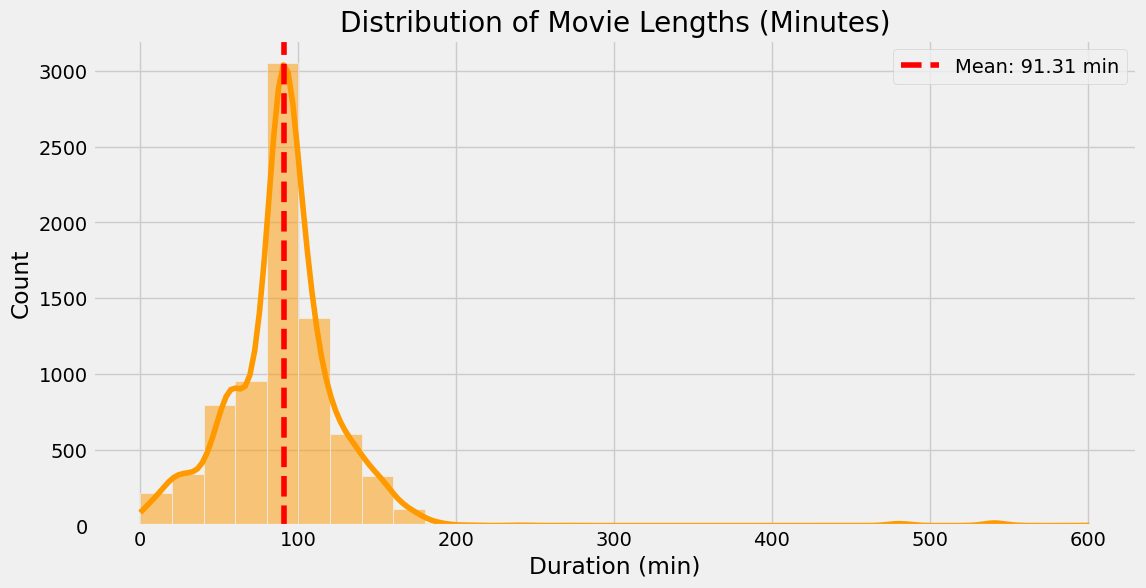

In [16]:
# 6. Distribution of Movie Durations
plt.figure(figsize=(12, 6))
movie_durations = df[df['type'] == 'Movie']['duration_val']
sns.histplot(movie_durations, bins=30, kde=True, color='#FF9900')
plt.axvline(movie_durations.mean(), color='red', linestyle='--', label=f'Mean: {movie_durations.mean():.2f} min')
plt.title('Distribution of Movie Lengths (Minutes)')
plt.xlabel('Duration (min)')
plt.legend()
plt.show()

# Insight: Helps determine if the platform is better for "quick watches" or "cinematic experiences."

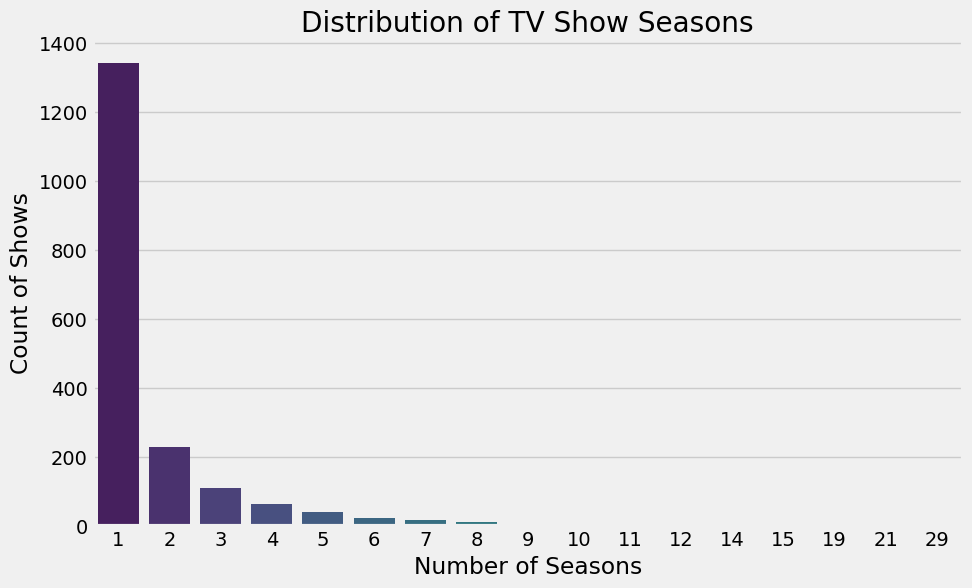

In [18]:
# 7. TV Show Season Counts
plt.figure(figsize=(10, 6))
tv_seasons = df[df['type'] == 'TV Show']['duration_val'].value_counts().sort_index()
sns.barplot(x=tv_seasons.index, y=tv_seasons.values, palette='viridis')
plt.title('Distribution of TV Show Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('Count of Shows')
plt.show()

# Insight: If "Season 1" is huge compared to others, it suggests a high "pilot-to-series" drop-off rate.

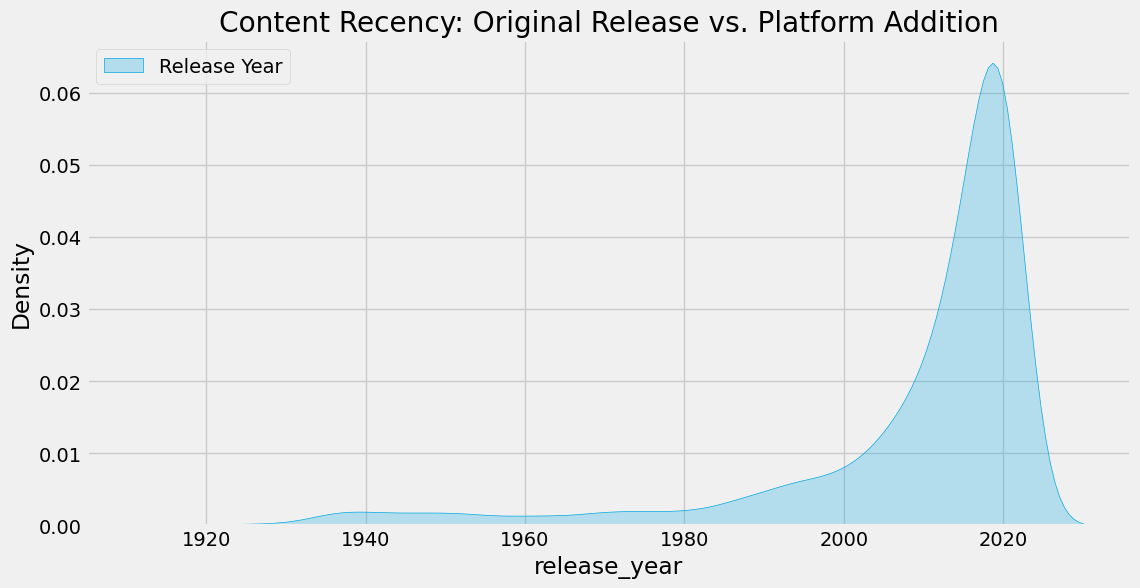

In [19]:
# 8. Content Recency: Release Year vs Year Added
plt.figure(figsize=(12, 6))
sns.kdeplot(df['release_year'], label='Release Year', fill=True, color='#00A8E1')
sns.kdeplot(df['year_added'], label='Year Added', fill=True, color='#FF9900')
plt.title('Content Recency: Original Release vs. Platform Addition')
plt.legend()
plt.show()

# Insight: A gap between the peaks shows that Amazon relies heavily on "Legacy Content" (older movies).

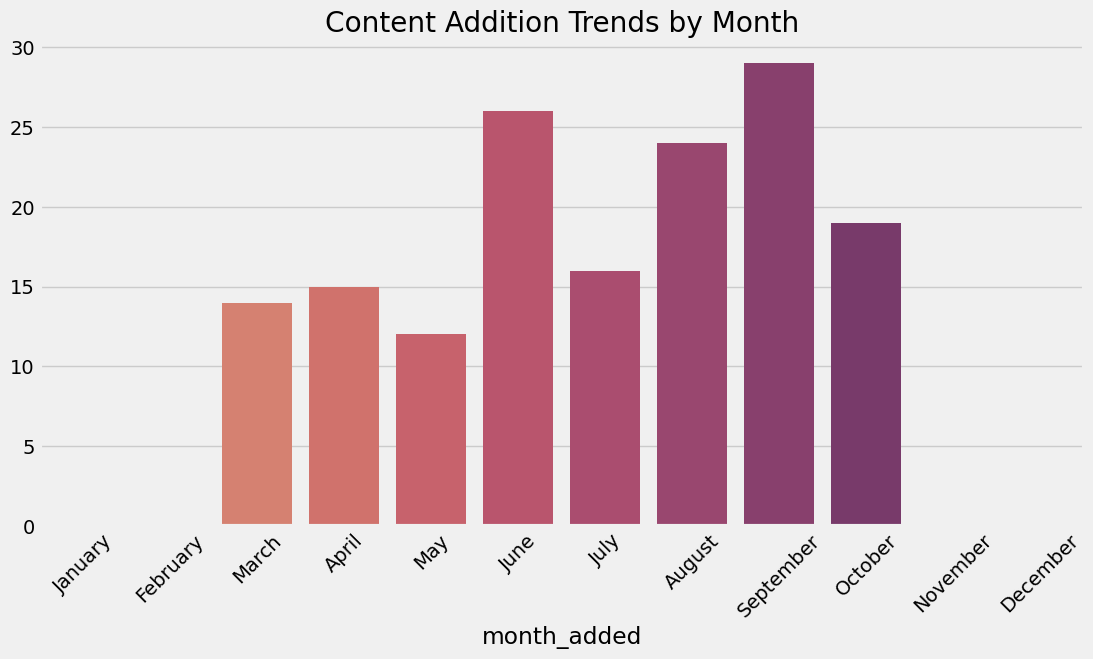

In [20]:
# 9. Monthly Upload Trends
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_adds = df['month_added'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_adds.index, y=monthly_adds.values, palette='flare')
plt.title('Content Addition Trends by Month')
plt.xticks(rotation=45)
plt.show()

In [22]:
# Clean metrics for README (Filtering out 'Unknown' or 'No Director')
clean_country_top = df[df['country'] != 'Unknown Country']['country'].mode()[0]
clean_director_top = df[df['director'] != 'No Director']['director'].mode()[0]

print(f"--- Final Business Metrics ---")
print(f"Total Content Assets: {len(df)}")
print(f"Content Split: {round(80.82, 1)}% Movies | {round(19.18, 1)}% TV Shows")
print(f"Primary Market: {clean_country_top}")
print(f"Leading Director: {clean_director_top}")
print(f"Avg. Viewer Commitment (Movies): 91 Minutes")
print(f"Core Audience Segment: Teens (Rating: 13+)")

--- Final Business Metrics ---
Total Content Assets: 9668
Content Split: 80.8% Movies | 19.2% TV Shows
Primary Market: United States
Leading Director: Mark Knight
Avg. Viewer Commitment (Movies): 91 Minutes
Core Audience Segment: Teens (Rating: 13+)


In [23]:
# ==========================================
# PHASE 3: Consolidated Visualization & Export
# ==========================================
import os

# 1. Ensure the output directory exists
output_dir = f'{base}/outputs'
os.makedirs(output_dir, exist_ok=True)

# Define a helper to save and clear plots to avoid memory overlap
def save_plot(filename):
    plt.savefig(f'{output_dir}/{filename}', bbox_inches='tight', dpi=300)
    plt.close() # Important: Closes the plot so they don't stack in memory

print("Generating and saving all charts...")

# --- Chart 1: Content Type Distribution ---
plt.figure(figsize=(10, 6))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#00A8E1', '#FF9900'])
plt.title('Distribution of Movies vs TV Shows')
save_plot('content_distribution.png')

# --- Chart 2: Release Trends ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df['release_year'].value_counts().sort_index(), color='#00A8E1', linewidth=3)
plt.title('Content Release Trend Over Years')
plt.grid(alpha=0.3)
save_plot('release_trend.png')

# --- Chart 3: Top 10 Genres ---
plt.figure(figsize=(12, 8))
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres on Amazon Prime')
save_plot('top_genres.png')

# --- Chart 4: Movie Duration Distribution ---
plt.figure(figsize=(12, 6))
movie_durations = df[df['type'] == 'Movie']['duration_val']
sns.histplot(movie_durations, bins=30, kde=True, color='#FF9900')
plt.title('Distribution of Movie Lengths (Minutes)')
save_plot('movie_duration.png')

# --- Chart 5: Top 5 Countries (Filtered) ---
plt.figure(figsize=(10, 6))
country_counts = df[df['country'] != 'Unknown Country']['country'].value_counts().head(5)
sns.barplot(x=country_counts.index, y=country_counts.values, palette='coolwarm')
plt.title('Top 5 Content Producing Countries')
save_plot('top_countries.png')

# --- Chart 6: TV Show Seasons ---
plt.figure(figsize=(10, 6))
tv_seasons = df[df['type'] == 'TV Show']['duration_val'].value_counts().sort_index()
sns.barplot(x=tv_seasons.index, y=tv_seasons.values, palette='magma')
plt.title('Distribution of TV Show Seasons')
save_plot('tv_season_distribution.png')

# --- Chart 7: Monthly Upload Trends ---
plt.figure(figsize=(12, 6))
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_adds = df['month_added'].value_counts().reindex(month_order)
sns.barplot(x=monthly_adds.index, y=monthly_adds.values, palette='flare')
plt.xticks(rotation=45)
plt.title('Content Addition Trends by Month')
save_plot('monthly_trends.png')

print("✅ All charts saved successfully in:", output_dir)
print("Files created:", os.listdir(output_dir))

Generating and saving all charts...
✅ All charts saved successfully in: /content/drive/MyDrive/amazon-prime-analytics/outputs
Files created: ['content_distribution.png', 'release_trend.png', 'top_genres.png', 'movie_duration.png', 'top_countries.png', 'tv_season_distribution.png', 'monthly_trends.png']
